[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Animal Verification Pipeline
Enter your text describing the animal: horses
Upload an image file:


Saving unnamed.png to unnamed.png


Downloading...
From (original): https://drive.google.com/uc?id=1Yz_DvxRTs4y0_6gBUsG1F4ODwXZgYH1w
From (redirected): https://drive.google.com/uc?id=1Yz_DvxRTs4y0_6gBUsG1F4ODwXZgYH1w&confirm=t&uuid=2d58cad7-95cd-480c-b7a6-49bee0f02096
To: /content/classifier_resnet18.pth
100%|██████████| 44.8M/44.8M [00:00<00:00, 59.8MB/s]


Downloading...
From: https://drive.google.com/uc?id=1Rs1c5DtyYB17zgcBK_MAFYsfAF1bklHs
To: /content/ner_tokenizer.zip
100%|██████████| 1.19M/1.19M [00:00<00:00, 78.4MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1KkjluZVzaBcO6SmKtXjwuN8i-P_VyhSm
From (redirected): https://drive.google.com/uc?id=1KkjluZVzaBcO6SmKtXjwuN8i-P_VyhSm&confirm=t&uuid=30605b60-a4b4-456d-8296-6934ada59a6a
To: /content/ner_model_weights.pth
100%|██████████| 496M/496M [00:05<00:00, 98.1MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Extracted animals from text: {'horse'}
Predicted from image: horse
Match? True
Does the text describe the image? -> Yes


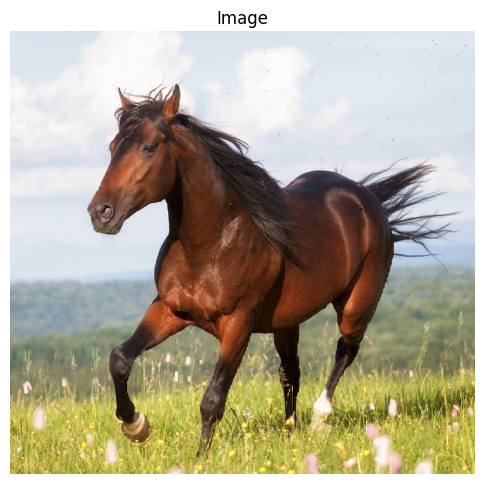

In [1]:
import os
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
from PIL import Image
from transformers import RobertaTokenizerFast, RobertaForTokenClassification
import gdown
from google.colab import files
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

# Google Drive IDs with weights and tokenizer
CLASSIFIER_DRIVE_ID = "1Yz_DvxRTs4y0_6gBUsG1F4ODwXZgYH1w"
NER_TOKENIZER_DRIVE_ID = "1Rs1c5DtyYB17zgcBK_MAFYsfAF1bklHs"
NER_WEIGHTS_DRIVE_ID = "1KkjluZVzaBcO6SmKtXjwuN8i-P_VyhSm"

# Local files
CLASSIFIER_WEIGHTS = "classifier_resnet18.pth"
NER_TOKENIZER_DIR = "ner_tokenizer"
NER_WEIGHTS = "ner_model_weights.pth"

# NER mappings
tag2id = {"O": 0, "B-ANIMAL": 1, "I-ANIMAL": 2}
id2tag = {v: k for k, v in tag2id.items()}

# class names
class_names_en = ["dog", "horse", "elephant", "butterfly", "chicken", "cat", "cow", "sheep", "spider", "squirrel"]

def download_from_drive(file_id: str, dest: str):
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, dest, quiet=False)

def ensure_models_present():
    # classifier weights
    if not os.path.exists(CLASSIFIER_WEIGHTS):
        print("Downloading classifier weights...")
        download_from_drive(CLASSIFIER_DRIVE_ID, CLASSIFIER_WEIGHTS)
    else:
        print("Classifier weights already present.")

    # NER tokenizer zip
    if not os.path.isdir(NER_TOKENIZER_DIR):
        print("Downloading NER tokenizer...")
        download_from_drive(NER_TOKENIZER_DRIVE_ID, NER_TOKENIZER_DIR + ".zip")
        import zipfile
        with zipfile.ZipFile(NER_TOKENIZER_DIR + ".zip", 'r') as zf:
            zf.extractall(NER_TOKENIZER_DIR)
        os.remove(NER_TOKENIZER_DIR + ".zip")
    else:
        print("NER tokenizer dir already exists.")

    # NER weights
    if not os.path.exists(NER_WEIGHTS):
        print("Downloading NER model weights...")
        download_from_drive(NER_WEIGHTS_DRIVE_ID, NER_WEIGHTS)
    else:
        print("NER weights already present.")

#Models

def load_ner_model_and_tokenizer():
    tokenizer = RobertaTokenizerFast.from_pretrained(NER_TOKENIZER_DIR)
    model = RobertaForTokenClassification.from_pretrained("roberta-base", num_labels=len(tag2id))
    state_dict = torch.load(NER_WEIGHTS, map_location=torch.device("cpu"))
    model.load_state_dict(state_dict)
    model.eval()
    return model, tokenizer

def load_classifier_model():
    model = models.resnet18(pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, len(class_names_en))
    state_dict = torch.load(CLASSIFIER_WEIGHTS, map_location=torch.device("cpu"))
    model.load_state_dict(state_dict)
    model.eval()
    return model

def animal_verification_pipeline(text: str, image_path: str) -> bool:
    ensure_models_present()

    # load models
    ner_model, ner_tokenizer = load_ner_model_and_tokenizer()
    classifier_model = load_classifier_model()

    # NER: extract animal mentions in text
    tokens = text.split()
    encoding = ner_tokenizer(tokens,
                             is_split_into_words=True,
                             return_tensors="pt",
                             add_special_tokens=True,
                             truncation=True,
                             padding="max_length",
                             max_length=64)
    word_ids = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        outputs = ner_model(**encoding)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=-1).squeeze().tolist()

    extracted_animals = set()
    previous_word_idx = None
    for i, widx in enumerate(word_ids):
        if widx is None:
            continue
        if widx != previous_word_idx:
            tag = id2tag[preds[i]]
            if tag.startswith("B-") or tag.startswith("I-"):
                lemma = lemmatizer.lemmatize(tokens[widx].lower(), pos='n')  # 'n' for noun
                extracted_animals.add(lemma)
        previous_word_idx = widx

    if not extracted_animals:
        print("No animals found in text.")
        return False

    # image classification
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = classifier_model(input_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
    predicted_animal = class_names_en[pred_idx]

    # result
    result = predicted_animal.lower() in extracted_animals

    print("Extracted animals from text:", extracted_animals)
    print("Predicted from image:", predicted_animal)
    print("Match?", result)

    return result

# DEMO

if __name__ == "__main__":
    print("Animal Verification Pipeline")
    user_text = input("Enter your text describing the animal: ")
    print("Upload an image file:")
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]

    ok = animal_verification_pipeline(user_text, image_path)

    print("Does the text describe the image? ->", "Yes" if ok else "No")

    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Image")
    plt.show()
